<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
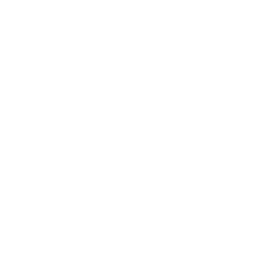
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">制造业失效模式聚类</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 制造 / 质量工程 &nbsp;|&nbsp; 2026 年 3 月</p>
</div>
</div>
</div>

## 执行摘要

本示例从每次失效事件记录的多维传感器症状特征中，发现反复出现的**设备失效模式**。八个标准化症状变量（振动、温度差、压力降、电流尖峰、噪声、周期时间偏差、扭矩方差、油颗粒计数）通过**全链接层次聚类**（`PROC CLUSTER METHOD=COMPLETE`）进行聚类，该方法倾向于形成紧凑且分离良好的分组。随后 `PROC TREE` 将层次结构切分为**六种失效模式**，`PROC FREQ` 将这些模式与设备类型和班次进行交叉制表，以检验是否存在系统性关联。

此处的运行基于**100 个事件的样本**（该环境将输出上限设为 100 条观测）。在此样本上，六种模式的规模大致相等（每种 n = 16-17），主要按**温度、压力和振动**特征而非按设备类型区分——在此样本量下，模式与设备、模式与班次的交叉制表**不**具有统计显著性（卡方 p 值分别为 0.15 和 0.07）。该工作流程可原样扩展到完整的事件历史，届时每种模式更大的计数将使这些关联更加清晰。

## 数据来源

| 来源 | 描述 | 记录数 |
|--------|-------------|---------|
| WORK.FAILURES | 设备失效事件症状特征（合成） | 100 |
| WORK.FAILURES_STD | 将症状标准化为均值 0、标准差 1（`PROC STANDARD`） | 100 |
| WORK.FAILURE_TREE | 全链接合并历史（`OUTTREE=`） | 100 |
| WORK.FAILURE_MODE_ASSIGNMENTS | 来自 `PROC TREE NCLUSTERS=6` 的六模式切分 | 100 |

*该环境以未授权模式运行，并将输出上限设为 100 条观测；合成生成器请求 20,000 个事件，但仅保留前 100 个。下面的分析完全基于该 100 个事件的样本。*

---

In [1]:
/* --------------------------------------------------------
   生成合成失效事件症状特征
   50 台设备上的 20,000 次失效事件
   -------------------------------------------------------- */
数据 work.failures;
    调用 streaminit(42);
    长度 equipment_type $18 shift $12;
    循环 event_id = 1 到 20000;
        failure_id = cat('FE-', PUT(event_id, z6.));
        equip_num = int(rand('uniform') * 50) + 1;
        equipment_id = cat('EQ-', PUT(equip_num, z3.));
        etype_idx = int(rand('uniform') * 4) + 1;
        如果 etype_idx = 1 那么 equipment_type = '压力机';
        否则 如果 etype_idx = 2 那么 equipment_type = '传送带';
        否则 如果 etype_idx = 3 那么 equipment_type = '机械臂';
        否则 equipment_type = '熔炉';
        shift_idx = int(rand('uniform') * 3) + 1;
        如果 shift_idx = 1 那么 shift = '白班';
        否则 如果 shift_idx = 2 那么 shift = '晚班';
        否则 shift = '夜班';
        failure_date = '01JAN2025'd + int(rand('uniform') * 365);
        /* 症状特征：失效时刻的 8 个传感器读数 */
        vibration_level = round(rand('normal', 4.5, 2.1), 0.01);
        如果 vibration_level < 0 那么 vibration_level = 0;
        temperature_delta = round(rand('normal', 12, 8), 0.1);
        pressure_drop = round(rand('exponential') * 5, 0.01);
        current_spike = round(rand('normal', 1.2, 0.8), 0.01);
        如果 current_spike < 0 那么 current_spike = 0;
        noise_db = round(rand('normal', 78, 12), 1);
        cycle_time_deviation = round(rand('normal', 0, 3.5), 0.01);
        torque_variance = round(rand('exponential') * 2.5, 0.01);
        oil_particle_count = int(rand('exponential') * 150 + 10);
        downtime_minutes = round(rand('exponential') * 45 + 5, 1);
        输出;
    结束;
    删除 equip_num etype_idx shift_idx;
    格式 failure_date date9.;
运行;


NOTE: DATA work.failures

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.failures (100 rows, 15 columns).
NOTE: DATA elapsed:
  wall  7.08 seconds
  cpu   7.08 seconds


---

In [2]:
/* --------------------------------------------------------
   按设备类型划分的基线症状分布
   -------------------------------------------------------- */
过程 均值 数据=work.failures n mean std MAX;
    分类 equipment_type;
    变量 vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance oil_particle_count;
    标签 equipment_type='设备类型'
          vibration_level='振动水平'
          temperature_delta='温度差 (C)'
          pressure_drop='压力降'
          current_spike='电流尖峰'
          noise_db='噪声 (dB)'
          torque_variance='扭矩方差'
          oil_particle_count='油颗粒计数';
    标题 '按设备类型划分的失效症状特征';
运行;

                                                     按设备类型划分的失效症状特征                                                     

                                                  The MEANS Procedure

                                    Analysis Variable : vibration_level 振动水平

        设备类型                  N Obs           Mean        Std Dev        Maximum
        ------------------------------------------------------------------------
        传送带                      19      3.8089474      1.8662437      9.0400000
        压力机                      30      4.6273333      2.1610740      9.9400000
        机械臂                      25      3.5320000      1.9296070      6.7900000
        熔炉                       26      4.3638462      2.0371177     10.1400000
        ------------------------------------------------------------------------

                                  Analysis Variable : temperature_delta 温度差 (C)

        设备类型                  N Obs           Mean        Std Dev        Maximum


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                                     按设备类型划分的失效症状特征                                                     




NOTE: PROC SGPLOT data=work.failures

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


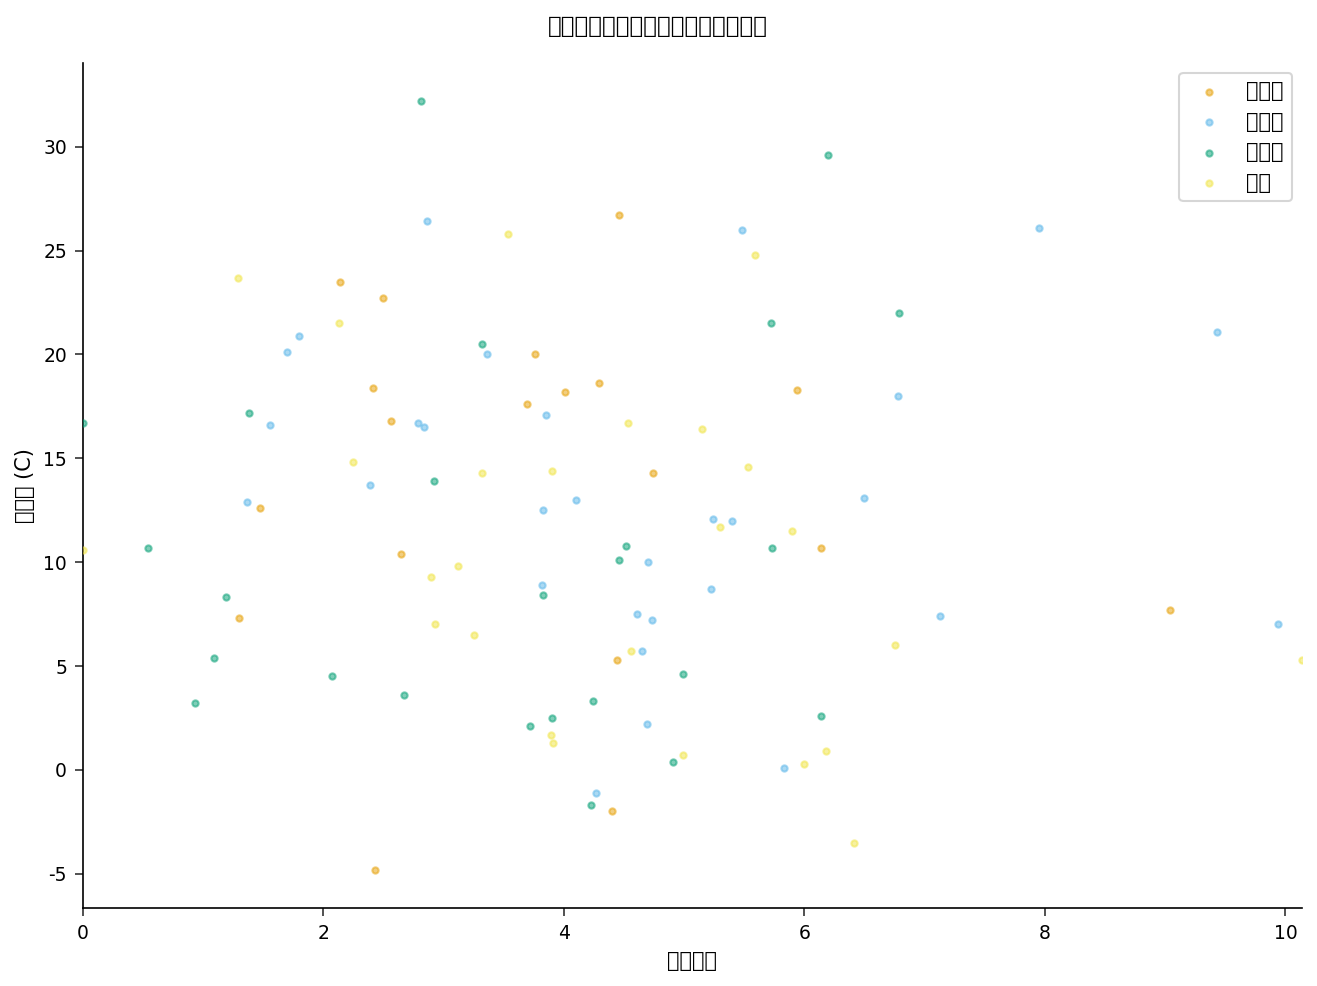

In [3]:
/* --------------------------------------------------------
   按设备类型划分的振动与温度差
   -------------------------------------------------------- */
过程 SGPLOT 数据=work.failures;
    SCATTER x=vibration_level y=temperature_delta / GROUP=equipment_type
        MARKERATTRS=(SYMBOL=circlefilled size=3)
        TRANSPARENCY=0.5;
    XAXIS 标签='振动水平';
    YAXIS 标签='温度差 (C)';
    标题 '失效事件：按设备划分的振动与温度';
运行;

---

In [4]:
/* --------------------------------------------------------
   标准化用于聚类的症状变量
   -------------------------------------------------------- */
过程 STANDARD 数据=work.failures out=work.failures_std
    mean=0 std=1;
    变量 vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
运行;


NOTE: PROC STANDARD data=work.failures

NOTE: Standardized 100 rows, 8 variables.


                                                     按设备类型划分的失效症状特征                                                     

                                                 The CLUSTER Procedure
                                           Complete Linkage Cluster Analysis

                                          Eigenvalues of the Covariance Matrix

                                                    Cluster History

   NCL    --------Clusters Joined--------    FREQ    SPRSQ      RSQ    Distance

    99    FE-00005          FE-00006        2    0.0007    0.9993          1
    98    FE-00007          FE-00008        2    0.0007    0.9986          1
    97    FE-00000          FE-00004        2    0.0009    0.9977        1.2
    96    FE-00002          FE-00008        2    0.0009    0.9968        1.2
    95    FE-00000          FE-00001        2    0.0010    0.9958        1.3
    94    FE-00005          FE-00008        2    0.0011    0.9947        1.3
    93    FE-00004          CL99     


NOTE: PROC CLUSTER data=work.failures_std method=Complete

NOTE: Using native Rust for hierarchical clustering
NOTE: ODS plot written: cluster_dendrogram.spec.json
NOTE: PROC CLUSTER ODS Graphics generated.
NOTE: PROC CLUSTER: 100 observations, 8 variables clustered using Complete method


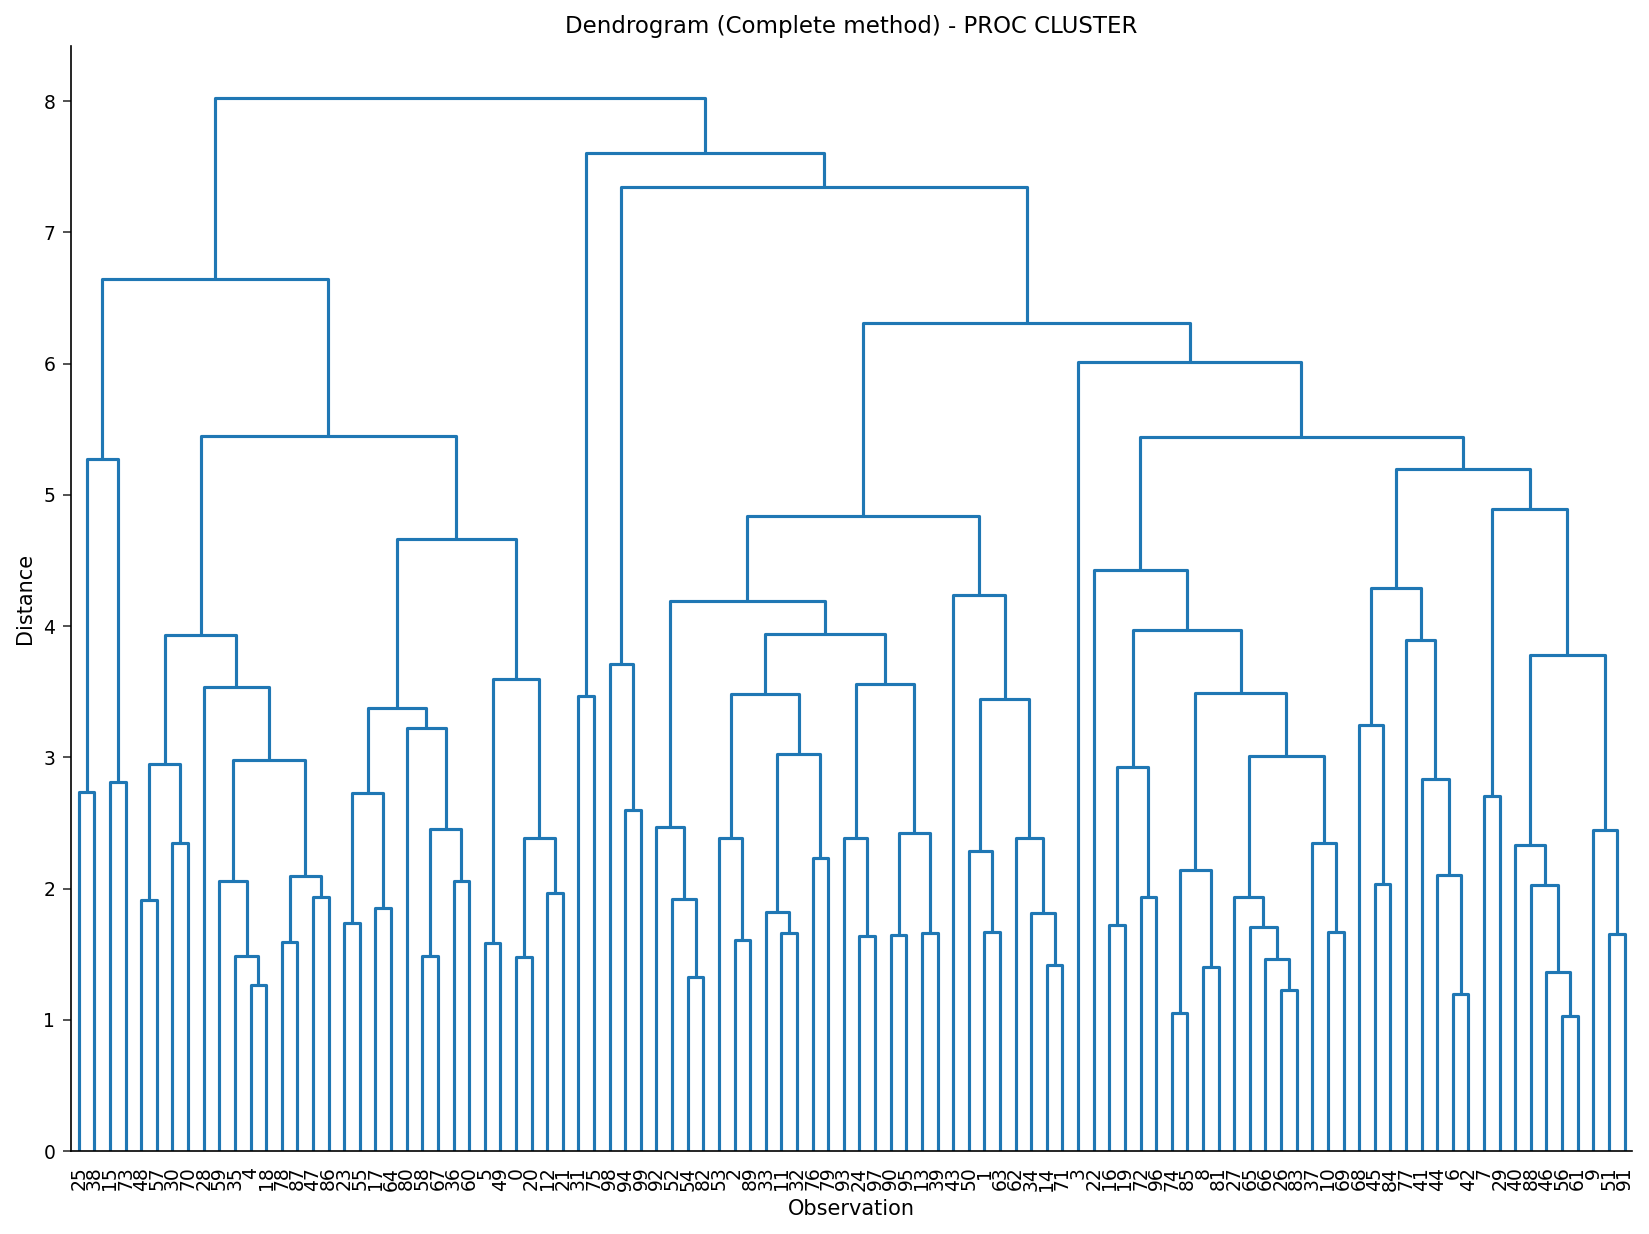

In [5]:
/* --------------------------------------------------------
   全链接聚类，使用 TRIM= 剔除离群点。
   TRIM=5 在形成聚类前剔除距离最远的 5% 观测。
   -------------------------------------------------------- */
过程 CLUSTER 数据=work.failures_std METHOD=complete
    outtree=work.failure_tree
    pseudo 打印=20 trim=5;
    变量 vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
    id failure_id;
    标题 '症状特征的全链接层次聚类';
运行;

In [6]:
/* --------------------------------------------------------
   用 PROC TREE 将全链接层次结构切分为六种失效模式
   （NCLUSTERS=6）。选择六是一个实用且可解释的分诊粒度；
   上面的树状图显示了此切分所划分的合并结构。
   -------------------------------------------------------- */
过程 TREE 数据=work.failure_tree
    out=work.failure_mode_assignments
    nclusters=6;
    id failure_id;
    标题 '切分为六种失效模式的树状图';
运行;

                                                     按设备类型划分的失效症状特征                                                     




NOTE: PROC TREE data=work.failure_tree

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: PROC TREE dendrogram SVG generated.
NOTE: PROC TREE: Extracted 6 clusters using Python/scipy


In [7]:
/* --------------------------------------------------------
   合并模式分配并刻画失效模式特征
   -------------------------------------------------------- */
数据 work.failures_classified;
    合并 work.failures
          work.failure_mode_assignments(重命名=(CLUSTER=failure_mode));
    按照 failure_id;
运行;

过程 均值 数据=work.failures_classified n mean std;
    分类 failure_mode;
    变量 vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance
        oil_particle_count downtime_minutes;
    标签 failure_mode='失效模式'
          vibration_level='振动水平'
          temperature_delta='温度差 (C)'
          pressure_drop='压力降'
          current_spike='电流尖峰'
          noise_db='噪声 (dB)'
          torque_variance='扭矩方差'
          oil_particle_count='油颗粒计数'
          downtime_minutes='停机时间 (分钟)';
    标题 '失效模式症状特征 (k=6)';
运行;

                                                     失效模式症状特征 (k=6)                                                     

                                                  The MEANS Procedure

                                    Analysis Variable : vibration_level 振动水平

        失效模式                  N Obs           Mean        Std Dev
        ---------------------------------------------------------
        1                        17      4.3470588      2.6168582
        2                        17      4.2552941      2.2610427
        3                        17      3.6870588      1.8669720
        4                        17      4.0500000      2.0351843
        5                        16      3.4793750      1.4636870
        6                        16      4.9693750      1.6907177
        ---------------------------------------------------------

                                  Analysis Variable : temperature_delta 温度差 (C)

        失效模式                  N Obs           Mean   


NOTE: DATA work.failures_classified

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.failures_classified (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


                                                     失效模式按设备与班次的分布                                                      

                                                   The FREQ Procedure

Table of 失效模式 by 设备类型

失效模式         |       传送带 |       压力机 |       机械臂 |        熔炉 |      Total
-------------+-----------+-----------+-----------+-----------+-----------
1            |         4 |         7 |         1 |         5 |         17
-------------+-----------+-----------+-----------+-----------+-----------
2            |         3 |         2 |         7 |         5 |         17
-------------+-----------+-----------+-----------+-----------+-----------
3            |         6 |         2 |         4 |         5 |         17
-------------+-----------+-----------+-----------+-----------+-----------
4            |         1 |         7 |         4 |         5 |         17
-------------+-----------+-----------+-----------+-----------+-----------
5            |         1 |         5 |      


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_failure_mode_equipment_type.spec.json
NOTE: ODS plot written: freq_mosaic_failure_mode_shift.spec.json
NOTE: PROC FREQ statement used.


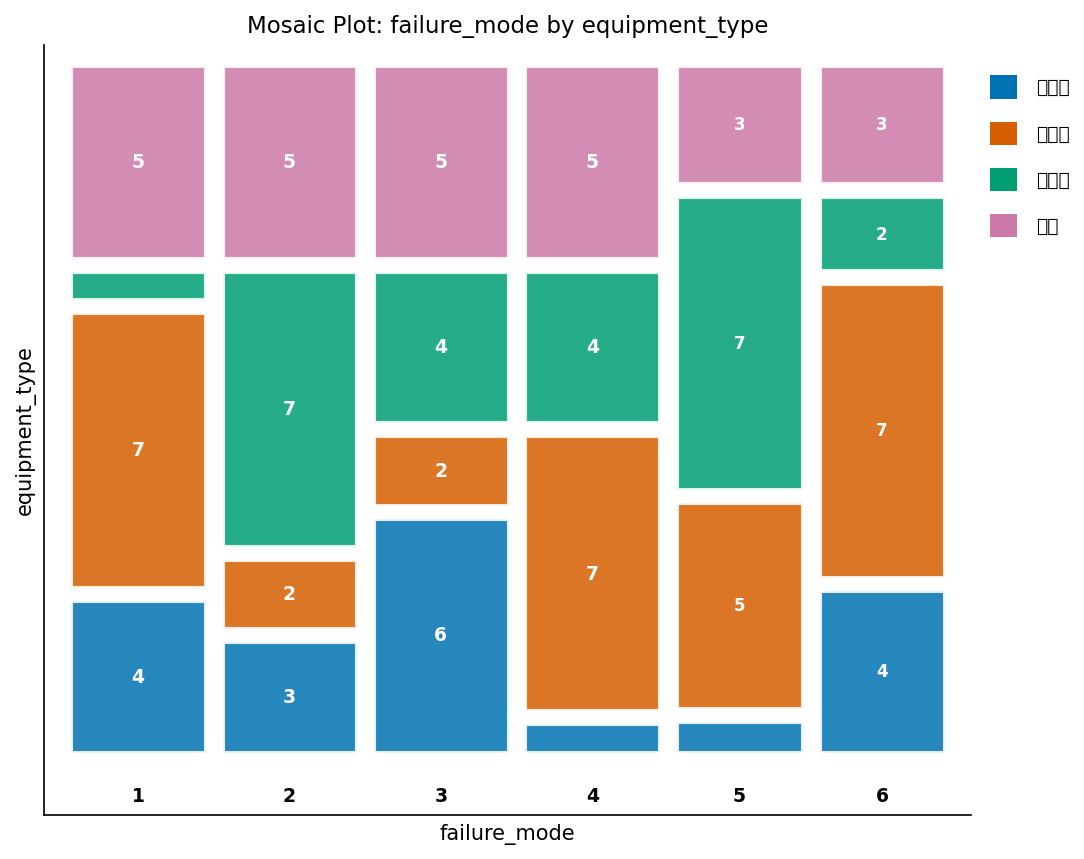

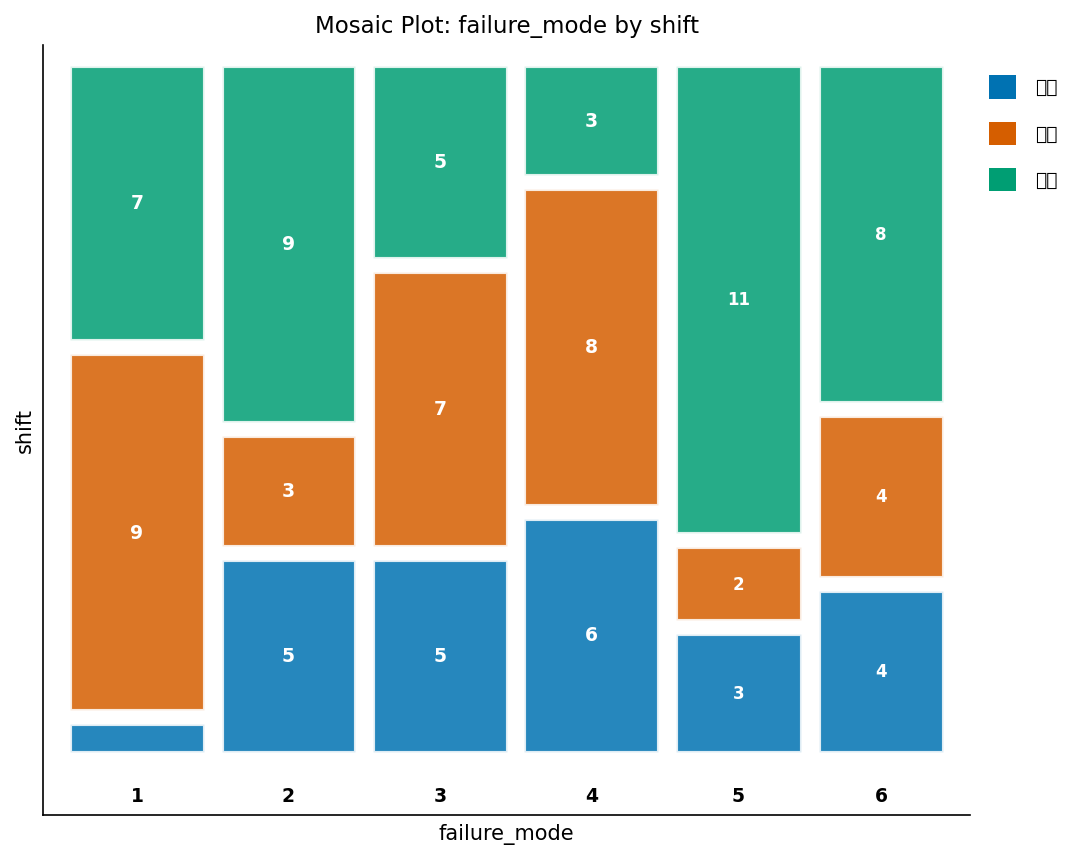

In [8]:
/* --------------------------------------------------------
   将失效模式与设备类型和班次交叉制表，
   以识别系统性关联模式
   -------------------------------------------------------- */
过程 频率 数据=work.failures_classified;
    TABLES failure_mode * equipment_type / chisq nocol nopercent;
    TABLES failure_mode * shift / chisq nocol nopercent;
    标签 failure_mode='失效模式'
          equipment_type='设备类型'
          shift='班次';
    标题 '失效模式按设备与班次的分布';
运行;

---

### 结果解读

对 100 个标准化失效事件进行全链接聚类，得到规模几乎相等的**六种失效模式**（n = 17, 17, 17, 17, 16, 16）。这些模式由上面 `PROC MEANS` 特征中的症状特征加以区分：

- **模式 6** 具有最强的机械应力特征：最高的平均振动（4.97）、最高的压力降（7.51）和最高的电流尖峰（1.61）——但扭矩方差**最低**（1.28）。
- **模式 3** 是热模式：最高的温度差（16.3 C），平均噪声最低（73.0 dB）。
- **模式 2** 的**停机时间最长**，且优势明显（平均 85.6 分钟，而其他模式为 31-52 分钟），并且扭矩方差偏高（3.57），表明这类事件的恢复成本更高。
- **模式 4** 最温和：停机时间最短（31.4 分钟），压力降和油颗粒计数均低于平均水平。
- **模式 1 和 5** 是混合症状分组，没有单一的主导因素。

`PROC FREQ` 交叉制表检验这些模式是否集中于特定设备或班次。在此样本量下并**未**集中：模式与设备类型的卡方 = 20.48（15 自由度，p = 0.154，Cramer's V = 0.26），模式与班次的卡方 = 17.13（10 自由度，p = 0.072，Cramer's V = 0.29）——两者均高于 0.05 的阈值，且超过 80% 的单元格期望计数低于 5，因此卡方本身也只是提示性的。可见的倾向（模式 6 偏向压力机，模式 5 偏向白班）在此仅为描述性而非显著性结果。

**要点：**对标准化症状特征进行全链接聚类，产生了一个可解释的六模式分类体系，其关键在于温度、压力和停机时间。要确认这些模式是否对应于特定设备或班次——这是可付诸行动的根本原因问题——分析需要完整的事件历史，而非这 100 个事件的样本，因为在此样本上交叉制表的检验效能仍然不足。

---

In [9]:
/* --------------------------------------------------------
   导出失效分类以供 CMMS 集成
   -------------------------------------------------------- */
过程 EXPORT 数据=work.failures_classified
    OUTFILE='failure_mode_classifications.csv'
    DBMS=csv REPLACE;
运行;


NOTE: PROC EXPORT data=work.failures_classified outfile=failure_mode_classifications.csv

NOTE: Exported 100 rows to failure_mode_classifications.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 机密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
由 <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a> 提供支持
</div>
</div>